# 1. Project goal

This notebook builds a simple RGB-D scene graph baseline for the `putAppleBowl1` real-world sequence.

The baseline intentionally stays small:

- Grounding DINO provides open-vocabulary bounding-box detections.
- No segmentation masks are used.
- Depth is estimated only from pixels inside each detected bounding box.
- Each object gets one representative 3D point from bbox center + median depth.
- Stable object IDs are assigned with existing tracker IDs if available, otherwise simple label-aware IoU matching.
- The only graph relation is `near`.
- Occlusion is represented only as quality flags, not as graph edges.
- The final output is a JSON file with per-frame graphs and a temporal consistency report.

## 2. Imports and configuration

In [1]:
from pathlib import Path
from collections import defaultdict, Counter
import csv
import json
import math
import pickle
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from PIL import Image
except ImportError:
    Image = None

try:
    import cv2
except ImportError:
    cv2 = None

try:
    import zarr
except ImportError:
    zarr = None

try:
    import imagecodecs.numcodecs as imagecodecs_numcodecs
    imagecodecs_numcodecs.register_codecs()
except Exception as exc:
    imagecodecs_numcodecs = None
    print(f"imagecodecs numcodecs registration not available yet: {exc}")

DATA_PATH = Path(r"C:/Users/gtomo/OneDrive/Desktop/Sem6/testingPhase1/Data/Data/Real Data/putAppleBowl1")
OUTPUT_DIR = Path("scene_graph_baseline_output")
OUTPUT_JSON = OUTPUT_DIR / "scene_graphs_with_temporal_report.json"

# Edit this prompt when the scene changes.
OBJECT_PROMPT = "apple. bowl. table. hand. robot gripper."

# Detection settings. Grounding DINO can be slow over a full RGB-D sequence, so cache results while iterating.
RUN_GROUNDING_DINO = True
BOX_THRESHOLD = 0.30
TEXT_THRESHOLD = 0.25

# Optional controls for classroom experiments.
MAX_FRAMES = 25          # Set None for the full sequence. Keep small while testing Grounding DINO on CPU.
FRAME_STRIDE = 1         # Example: 5 to process every fifth frame.

# Grounding DINO model settings. The tiny model is practical on CPU; change to base for stronger detections.
GROUNDING_DINO_MODEL_ID = "IDEA-Research/grounding-dino-tiny"
GROUNDING_DINO_MODEL_PATH = None  # Optional local snapshot/checkpoint folder. Leave None to use Hugging Face cache.
GROUNDING_DINO_LOCAL_FILES_ONLY = True  # Already downloaded on this machine. Set False once if you need to download.
USE_DETECTION_CACHE = True
FORCE_RERUN_GROUNDING_DINO = False
DETECTION_CACHE_PATH = OUTPUT_DIR / "grounding_dino_detections.json"

# Depth quality thresholds.
VALID_DEPTH_RATIO_THRESHOLD = 0.30
MIN_VALID_PIXELS = 50
DEPTH_IQR_THRESHOLD_M = 0.20
DEPTH_JUMP_THRESHOLD_M = 0.30

# Simple tracking and graph thresholds.
TRACKING_IOU_THRESHOLD = 0.30
NEAR_THRESHOLD_M = 0.40

# Occlusion-quality flag thresholds.
OCCLUSION_IOU_THRESHOLD = 0.20
OCCLUSION_DEPTH_MARGIN_M = 0.10
VALID_RATIO_DROP_THRESHOLD = 0.25
IQR_INCREASE_THRESHOLD_M = 0.15

# Active REFLECT RealSense intrinsics, used unless dataset-specific calibration is discovered.
REFLECT_INTRINSICS = np.array([
    [914.27246, 0.0, 647.0733],
    [0.0, 913.2658, 356.32526],
    [0.0, 0.0, 1.0],
], dtype=float)

COORDINATE_TYPE = "metric_3d_from_realsense_intrinsics"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", 120)

## 3. Inspect dataset folder

In [2]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
DEPTH_EXTS = {".npy", ".npz", ".png", ".tif", ".tiff", ".exr"}
DETECTION_EXTS = {".json", ".jsonl", ".csv", ".pkl", ".pickle"}
CALIBRATION_KEYWORDS = ("intrinsic", "intrinsics", "calib", "calibration", "camera")


def discover_dataset(root: Path):
    all_paths = [p for p in root.rglob("*") if p.name not in {".DS_Store"}]
    folders = sorted([p for p in all_paths if p.is_dir()])
    files = sorted([p for p in all_paths if p.is_file()])

    rgb_files = [
        p for p in files
        if p.suffix.lower() in IMAGE_EXTS
        or "color" in str(p).lower()
        or "rgb" in str(p).lower()
    ]
    depth_files = [
        p for p in files
        if p.suffix.lower() in DEPTH_EXTS
        or "depth" in str(p).lower()
    ]
    detection_files = [
        p for p in files
        if p.suffix.lower() in DETECTION_EXTS
        and any(k in p.name.lower() for k in ("det", "track", "bbox", "grounding", "dino", "gdino"))
    ]
    calibration_files = [
        p for p in files
        if any(k in p.name.lower() for k in CALIBRATION_KEYWORDS)
        and p.suffix.lower() in {".json", ".yaml", ".yml", ".txt", ".npz", ".npy", ".csv"}
    ]

    print(f"Dataset root: {root}")
    print(f"Discovered folders: {len(folders)}")
    for p in folders[:30]:
        print("  folder:", p.relative_to(root))
    if len(folders) > 30:
        print(f"  ... {len(folders) - 30} more folders")

    print(f"\nDetected RGB files/candidates: {len(rgb_files)}")
    for p in rgb_files[:20]:
        print("  rgb:", p.relative_to(root))
    if len(rgb_files) > 20:
        print(f"  ... {len(rgb_files) - 20} more RGB candidates")

    print(f"\nDetected depth files/candidates: {len(depth_files)}")
    for p in depth_files[:20]:
        print("  depth:", p.relative_to(root))
    if len(depth_files) > 20:
        print(f"  ... {len(depth_files) - 20} more depth candidates")

    print(f"\nDetected detection/tracker files: {len(detection_files)}")
    for p in detection_files:
        print("  detection:", p.relative_to(root))

    print(f"\nDetected calibration/intrinsics files: {len(calibration_files)}")
    for p in calibration_files:
        print("  calibration:", p.relative_to(root))

    return {
        "folders": folders,
        "files": files,
        "rgb_files": rgb_files,
        "depth_files": depth_files,
        "detection_files": detection_files,
        "calibration_files": calibration_files,
    }


discovered = discover_dataset(DATA_PATH)

Dataset root: C:\Users\gtomo\OneDrive\Desktop\Sem6\testingPhase1\Data\Data\Real Data\putAppleBowl1
Discovered folders: 17
  folder: replay_buffer.zarr
  folder: replay_buffer.zarr\data
  folder: replay_buffer.zarr\data\action
  folder: replay_buffer.zarr\data\gripper_force
  folder: replay_buffer.zarr\data\gripper_pos
  folder: replay_buffer.zarr\data\gripper_state
  folder: replay_buffer.zarr\data\robot_eef_pose
  folder: replay_buffer.zarr\data\robot_eef_pose_vel
  folder: replay_buffer.zarr\data\robot_joint
  folder: replay_buffer.zarr\data\robot_joint_vel
  folder: replay_buffer.zarr\data\stage
  folder: replay_buffer.zarr\data\timestamp
  folder: replay_buffer.zarr\meta
  folder: replay_buffer.zarr\meta\episode_ends
  folder: videos
  folder: videos\color
  folder: videos\depth

Detected RGB files/candidates: 2098
  rgb: videos\color\.zarray
  rgb: videos\color\0.0.0.0
  rgb: videos\color\1.0.0.0
  rgb: videos\color\10.0.0.0
  rgb: videos\color\100.0.0.0
  rgb: videos\color\1000.0

## 4. Load RGB-D sequence

In [3]:
def natural_frame_key(path: Path):
    # Zarr chunk files here are named like 0.0.0.0 for color and 0.0.0 for depth.
    nums = re.findall(r"\d+", path.name)
    return tuple(int(n) for n in nums) if nums else (10**12, path.name)


def open_zarr_array(path: Path):
    if zarr is None:
        raise ImportError(
            "zarr is not installed. Install zarr and imagecodecs to read the JPEG-XL-compressed RGB-D arrays."
        )
    try:
        return zarr.open(str(path), mode="r")
    except Exception as exc:
        if "imagecodecs_jpegxl" in str(exc):
            raise RuntimeError(
                "The RGB-D Zarr arrays use the imagecodecs_jpegxl compressor, but that codec is not "
                "registered/available. Install or update imagecodecs, then run "
                "`import imagecodecs.numcodecs; imagecodecs.numcodecs.register_codecs()` before opening Zarr."
            ) from exc
        raise


def build_rgbd_index(root: Path, max_frames=None, stride=1):
    color_zarr_path = root / "videos" / "color"
    depth_zarr_path = root / "videos" / "depth"
    rgb_video_path = root / "videos" / "color.mp4"

    color_array = None
    depth_array = None
    if color_zarr_path.exists() and (color_zarr_path / ".zarray").exists():
        color_array = open_zarr_array(color_zarr_path)
    if depth_zarr_path.exists() and (depth_zarr_path / ".zarray").exists():
        depth_array = open_zarr_array(depth_zarr_path)

    if color_array is not None and depth_array is not None:
        n = min(int(color_array.shape[0]), int(depth_array.shape[0]))
        frame_ids = list(range(0, n, stride))
        if max_frames is not None:
            frame_ids = frame_ids[:max_frames]
        sequence = pd.DataFrame({"frame_id": frame_ids})
        print(f"Using Zarr RGB-D arrays.")
        print(f"  color shape: {color_array.shape}, dtype: {color_array.dtype}")
        print(f"  depth shape: {depth_array.shape}, dtype: {depth_array.dtype}")
        print(f"  indexed frames: {len(sequence)}")
        return sequence, color_array, depth_array, rgb_video_path

    raise FileNotFoundError(
        "Could not find both videos/color and videos/depth Zarr arrays. "
        "Check discovered RGB/depth files above and adapt build_rgbd_index if needed."
    )


def load_rgb_frame(frame_id: int):
    rgb = np.asarray(color_array[frame_id])
    return rgb


def load_depth_frame_raw(frame_id: int):
    depth = np.asarray(depth_array[frame_id]).astype(np.float32)
    return depth


sequence_df, color_array, depth_array, rgb_video_path = build_rgbd_index(
    DATA_PATH, max_frames=MAX_FRAMES, stride=FRAME_STRIDE
)
sequence_df.head()

Using Zarr RGB-D arrays.
  color shape: (2096, 720, 1280, 3), dtype: uint8
  depth shape: (2096, 720, 1280), dtype: uint16
  indexed frames: 25


,frame_id
0,0
1,1
2,2
3,3
4,4


## 5. Camera intrinsics

In [4]:
def try_load_intrinsics_from_file(path: Path):
    text = None
    try:
        if path.suffix.lower() == ".npy":
            arr = np.load(path)
            if arr.shape == (3, 3):
                return arr.astype(float), str(path)
        if path.suffix.lower() == ".npz":
            data = np.load(path)
            for key in data.files:
                arr = data[key]
                if arr.shape == (3, 3):
                    return arr.astype(float), f"{path}:{key}"
        if path.suffix.lower() == ".json":
            obj = json.loads(path.read_text())
            candidates = [
                obj.get("intrinsics"),
                obj.get("intrinsic_matrix"),
                obj.get("camera_matrix"),
                obj.get("K"),
            ]
            for cand in candidates:
                arr = np.array(cand, dtype=float) if cand is not None else None
                if arr is not None and arr.shape == (3, 3):
                    return arr, str(path)
            if all(k in obj for k in ("fx", "fy", "cx", "cy")):
                return np.array([[obj["fx"], 0, obj["cx"]], [0, obj["fy"], obj["cy"]], [0, 0, 1]], dtype=float), str(path)
        if path.suffix.lower() in {".txt", ".csv", ".yaml", ".yml"}:
            text = path.read_text(errors="ignore")
    except Exception as exc:
        print(f"Could not parse intrinsics candidate {path}: {exc}")
        return None, None

    if text:
        numbers = [float(x) for x in re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", text)]
        if len(numbers) >= 9:
            arr = np.array(numbers[:9], dtype=float).reshape(3, 3)
            if arr[2, 2] != 0:
                return arr, str(path)
    return None, None


intrinsics_matrix = None
intrinsics_source = "REFLECT_default_realsense"

for candidate in discovered["calibration_files"]:
    K, src = try_load_intrinsics_from_file(candidate)
    if K is not None:
        intrinsics_matrix = K
        intrinsics_source = "dataset"
        print(f"Using dataset intrinsics from {src}")
        break

if intrinsics_matrix is None:
    intrinsics_matrix = REFLECT_INTRINSICS.copy()
    print("No dataset-specific intrinsics found. Using active REFLECT RealSense intrinsics.")

fx, fy = float(intrinsics_matrix[0, 0]), float(intrinsics_matrix[1, 1])
cx, cy = float(intrinsics_matrix[0, 2]), float(intrinsics_matrix[1, 2])
print(intrinsics_matrix)

No dataset-specific intrinsics found. Using active REFLECT RealSense intrinsics.
[[914.27246   0.      647.0733 ]
 [  0.      913.2658  356.32526]
 [  0.        0.        1.     ]]


## 6. Grounding DINO detection / load detections

In [5]:
def normalize_label(label):
    return str(label).strip().lower().replace("_", " ")


def xywh_to_xyxy(x, y, w, h):
    return [float(x), float(y), float(x + w), float(y + h)]


def cxcywh_to_xyxy(cx_, cy_, w, h, image_width, image_height, normalized=True):
    if normalized:
        cx_, w = cx_ * image_width, w * image_width
        cy_, h = cy_ * image_height, h * image_height
    return [float(cx_ - w / 2), float(cy_ - h / 2), float(cx_ + w / 2), float(cy_ + h / 2)]


def clip_bbox_xyxy(bbox, width, height):
    x1, y1, x2, y2 = [float(v) for v in bbox]
    x1 = max(0.0, min(width - 1.0, x1))
    y1 = max(0.0, min(height - 1.0, y1))
    x2 = max(0.0, min(width - 1.0, x2))
    y2 = max(0.0, min(height - 1.0, y2))
    if x2 < x1:
        x1, x2 = x2, x1
    if y2 < y1:
        y1, y2 = y2, y1
    return [x1, y1, x2, y2]


def standardize_detection(raw, frame_id, det_id, image_width=1280, image_height=720):
    label = raw.get("label", raw.get("class", raw.get("name", raw.get("phrase", "object"))))
    score = raw.get("score", raw.get("confidence", raw.get("logit", raw.get("prob", 1.0))))

    if "bbox_xyxy" in raw:
        bbox = raw["bbox_xyxy"]
    elif "bbox" in raw and len(raw["bbox"]) == 4:
        bbox = raw["bbox"]
        # Heuristic: normalized cxcywh is common for Grounding DINO.
        if max(map(float, bbox)) <= 1.5:
            bbox = cxcywh_to_xyxy(*map(float, bbox), image_width, image_height, normalized=True)
    elif all(k in raw for k in ("x1", "y1", "x2", "y2")):
        bbox = [raw["x1"], raw["y1"], raw["x2"], raw["y2"]]
    elif all(k in raw for k in ("x", "y", "w", "h")):
        bbox = xywh_to_xyxy(raw["x"], raw["y"], raw["w"], raw["h"])
    elif all(k in raw for k in ("cx", "cy", "w", "h")):
        normalized = max(abs(float(raw[k])) for k in ("cx", "cy", "w", "h")) <= 1.5
        bbox = cxcywh_to_xyxy(raw["cx"], raw["cy"], raw["w"], raw["h"], image_width, image_height, normalized)
    else:
        raise ValueError(f"Cannot find bbox fields in detection: {raw}")

    out = {
        "frame_id": int(raw.get("frame_id", frame_id)),
        "det_id": int(raw.get("det_id", det_id)),
        "label": normalize_label(label),
        "score": float(score),
        "bbox_xyxy": clip_bbox_xyxy(bbox, image_width, image_height),
    }
    if "object_id" in raw:
        out["object_id"] = str(raw["object_id"])
    elif "track_id" in raw:
        out["object_id"] = str(raw["track_id"])
    return out


def load_detection_file(path: Path, image_width=1280, image_height=720):
    rows = []
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        records = df.to_dict("records")
    elif path.suffix.lower() in {".pkl", ".pickle"}:
        with open(path, "rb") as f:
            obj = pickle.load(f)
        records = obj if isinstance(obj, list) else obj.get("detections", obj.get("frames", []))
    elif path.suffix.lower() == ".jsonl":
        records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    else:
        obj = json.loads(path.read_text())
        if isinstance(obj, list):
            records = obj
        elif "detections" in obj:
            records = obj["detections"]
        elif "frames" in obj:
            records = []
            for frame in obj["frames"]:
                for det in frame.get("detections", frame.get("nodes", [])):
                    det = dict(det)
                    det.setdefault("frame_id", frame.get("frame_id"))
                    records.append(det)
        else:
            records = []

    det_id_counter = defaultdict(int)
    for rec in records:
        if "nodes" in rec:
            continue
        frame_id = int(rec.get("frame_id", rec.get("frame", 0)))
        det_id = int(rec.get("det_id", det_id_counter[frame_id]))
        det_id_counter[frame_id] += 1
        rows.append(standardize_detection(rec, frame_id, det_id, image_width, image_height))
    return rows


def load_existing_detections(detection_files):
    all_detections = []
    for path in detection_files:
        try:
            dets = load_detection_file(path)
            print(f"Loaded {len(dets)} detections from {path}")
            all_detections.extend(dets)
        except Exception as exc:
            print(f"Skipped detection candidate {path}: {exc}")
    return all_detections


def save_detection_cache(detections, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "metadata": {
            "detector": f"Grounding DINO via transformers: {GROUNDING_DINO_MODEL_ID}",
            "object_prompt": OBJECT_PROMPT,
            "box_threshold": BOX_THRESHOLD,
            "text_threshold": TEXT_THRESHOLD,
            "uses_masks": False,
        },
        "detections": detections,
    }
    path.write_text(json.dumps(make_json_safe(payload) if "make_json_safe" in globals() else payload, indent=2), encoding="utf-8")
    print(f"Saved Grounding DINO detection cache: {path.resolve()}")


def load_detection_cache(path: Path):
    if not path.exists():
        return []
    obj = json.loads(path.read_text(encoding="utf-8"))
    records = obj.get("detections", obj if isinstance(obj, list) else [])
    print(f"Loaded {len(records)} cached Grounding DINO detections from {path.resolve()}")
    return records


def resolve_grounding_dino_model_source():
    if GROUNDING_DINO_MODEL_PATH:
        model_path = Path(GROUNDING_DINO_MODEL_PATH)
        if not model_path.exists():
            raise FileNotFoundError(f"GROUNDING_DINO_MODEL_PATH does not exist: {model_path}")
        return str(model_path)

    try:
        from huggingface_hub import snapshot_download
        # Resolving to an actual snapshot folder avoids repeated metadata checks during offline runs.
        return snapshot_download(
            GROUNDING_DINO_MODEL_ID,
            local_files_only=GROUNDING_DINO_LOCAL_FILES_ONLY,
        )
    except Exception as exc:
        print("Could not resolve Grounding DINO from the local Hugging Face cache.")
        print(f"Model id: {GROUNDING_DINO_MODEL_ID}")
        print("If this is the first run on this machine, set GROUNDING_DINO_LOCAL_FILES_ONLY=False and rerun this cell once.")
        raise exc


def load_hf_grounding_dino_model():
    try:
        import torch
        from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
    except Exception as exc:
        raise ImportError(
            "Grounding DINO through transformers needs torch and transformers. Install with: "
            "pip install torch torchvision transformers accelerate huggingface_hub"
        ) from exc

    model_source = resolve_grounding_dino_model_source()
    try:
        processor = AutoProcessor.from_pretrained(model_source, local_files_only=True)
        model = AutoModelForZeroShotObjectDetection.from_pretrained(model_source, local_files_only=True)
    except Exception as exc:
        print("Could not load the Grounding DINO model weights from the resolved model source.")
        print(f"Resolved model source: {model_source}")
        print("If packages are missing, install: pip install torch torchvision transformers accelerate huggingface_hub")
        raise exc

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    print(f"Loaded Grounding DINO model {GROUNDING_DINO_MODEL_ID} from {model_source} on {device}")
    return processor, model, torch, device


def post_process_grounding_dino(processor, outputs, input_ids, image_height, image_width):
    # Transformers versions differ: older/newer processors use either threshold or box_threshold.
    try:
        result = processor.post_process_grounded_object_detection(
            outputs,
            input_ids,
            threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[(image_height, image_width)],
        )[0]
    except TypeError:
        result = processor.post_process_grounded_object_detection(
            outputs,
            input_ids,
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[(image_height, image_width)],
        )[0]
    return result


def run_grounding_dino_on_sequence(sequence):
    if Image is None:
        raise ImportError("PIL is required to convert RGB arrays into images for Grounding DINO.")

    processor, model, torch, device = load_hf_grounding_dino_model()
    detections = []

    frame_ids = sequence["frame_id"].tolist()
    print(f"Running Grounding DINO on {len(frame_ids)} frames.")
    print("Tip: on CPU, keep MAX_FRAMES small while testing; set MAX_FRAMES=None for the full sequence when ready.")

    for local_idx, frame_id in enumerate(frame_ids, start=1):
        rgb = load_rgb_frame(int(frame_id))
        image = Image.fromarray(rgb)
        image_width, image_height = image.size

        inputs = processor(images=image, text=OBJECT_PROMPT, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)

        result = post_process_grounding_dino(
            processor,
            outputs,
            inputs.input_ids,
            image_height=image_height,
            image_width=image_width,
        )

        boxes = result.get("boxes", [])
        scores = result.get("scores", [])
        labels = result.get("text_labels", result.get("labels", []))
        if hasattr(boxes, "detach"):
            boxes = boxes.detach().cpu().numpy()
        if hasattr(scores, "detach"):
            scores = scores.detach().cpu().numpy()

        for det_id, (bbox, score, label) in enumerate(zip(boxes, scores, labels)):
            raw = {
                "frame_id": int(frame_id),
                "det_id": int(det_id),
                "label": str(label),
                "score": float(score),
                "bbox_xyxy": [float(v) for v in bbox],
            }
            detections.append(standardize_detection(raw, frame_id, det_id, image_width, image_height))

        if local_idx % 5 == 0 or local_idx == len(frame_ids):
            print(f"  processed {local_idx}/{len(frame_ids)} frames, detections so far: {len(detections)}")

    return detections


# Detection priority:
# 1. Reuse cached Grounding DINO detections for frames already processed.
# 2. If RUN_GROUNDING_DINO=True, run Grounding DINO for any indexed frames missing from the cache.
# 3. Fall back to detection/tracker files discovered in the dataset only if the detector is disabled or unavailable.
detections = []
detector_name = "Grounding DINO or loaded detections"
sequence_frame_ids = set(int(v) for v in sequence_df["frame_id"].tolist())

if USE_DETECTION_CACHE and DETECTION_CACHE_PATH.exists() and not FORCE_RERUN_GROUNDING_DINO:
    detections = load_detection_cache(DETECTION_CACHE_PATH)
    detections = [d for d in detections if int(d["frame_id"]) in sequence_frame_ids]
    detector_name = f"Grounding DINO cached: {GROUNDING_DINO_MODEL_ID}"

cached_frame_ids = {int(d["frame_id"]) for d in detections}
missing_frame_ids = sorted(sequence_frame_ids - cached_frame_ids)

if RUN_GROUNDING_DINO and (FORCE_RERUN_GROUNDING_DINO or missing_frame_ids):
    if FORCE_RERUN_GROUNDING_DINO:
        print("FORCE_RERUN_GROUNDING_DINO=True, ignoring the detection cache for this run.")
        detections = []
        missing_frame_ids = sorted(sequence_frame_ids)
    else:
        print(f"Detection cache is missing {len(missing_frame_ids)} indexed frames; running Grounding DINO for those frames.")

    missing_sequence_df = sequence_df[sequence_df["frame_id"].isin(missing_frame_ids)].copy()
    new_detections = run_grounding_dino_on_sequence(missing_sequence_df)
    detections = detections + new_detections
    detections = sorted(detections, key=lambda d: (int(d["frame_id"]), int(d["det_id"])))
    detector_name = f"Grounding DINO via transformers: {GROUNDING_DINO_MODEL_ID}"
    save_detection_cache(detections, DETECTION_CACHE_PATH)

if not detections:
    detections = load_existing_detections(discovered["detection_files"])
    detector_name = "loaded detections" if detections else detector_name

# Keep only detections for the indexed sequence frames. This matters when a cache was made with a different MAX_FRAMES.
detections = [d for d in detections if int(d["frame_id"]) in sequence_frame_ids]

detections_by_frame = defaultdict(list)
for det in detections:
    detections_by_frame[int(det["frame_id"])].append(det)

print(f"Standardized detections: {len(detections)}")
print(f"Frames with detections: {len(detections_by_frame)}")
if len(detections) == 0:
    print("No detections were produced. Check the prompt, thresholds, model cache, or set GROUNDING_DINO_LOCAL_FILES_ONLY=False once to download weights.")
pd.DataFrame(detections).head()

Loaded 150 cached Grounding DINO detections from C:\Users\gtomo\OneDrive\Desktop\Sem6\testingPhase1\scene_graph_baseline_output\grounding_dino_detections.json
Standardized detections: 150
Frames with detections: 25


,frame_id,det_id,label,score,bbox_xyxy
0,0,0,apple,0.795349,"[20.188608169555664, 562.786865234375, 108.89144897460938, 641.8300170898438]"
1,0,1,robot gripper,0.632883,"[377.709228515625, 255.7809600830078, 453.21484375, 388.48883056640625]"
2,0,2,bowl,0.539588,"[180.59983825683594, 459.7231140136719, 325.5458984375, 587.8544311523438]"
3,0,3,table,0.533853,"[0.5013275146484375, 421.9635009765625, 359.58453369140625, 718.9507446289062]"
4,0,4,bowl,0.454152,"[514.3271484375, 587.080322265625, 568.2727661132812, 639.0792236328125]"


## 7. Assign stable object IDs

In [6]:
def bbox_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    denom = area_a + area_b - inter
    return float(inter / denom) if denom > 0 else 0.0


def assign_stable_ids(sequence, detections_by_frame):
    # If detections already contain tracker IDs, preserve them and only normalize labels.
    has_external_ids = any("object_id" in det for dets in detections_by_frame.values() for det in dets)
    if has_external_ids:
        for dets in detections_by_frame.values():
            for det in dets:
                if "object_id" not in det:
                    det["object_id"] = f"{det['label']}_unknown_{det['det_id']}"
        print("Using object_id / track_id values from detection files.")
        return detections_by_frame

    next_index = defaultdict(int)
    prev_dets = []

    for frame_id in sequence["frame_id"].tolist():
        current = detections_by_frame.get(int(frame_id), [])
        used_prev = set()
        current_sorted = sorted(current, key=lambda d: d.get("score", 0), reverse=True)

        for det in current_sorted:
            best_iou, best_prev_idx, best_object_id = 0.0, None, None
            for idx, prev in enumerate(prev_dets):
                if idx in used_prev:
                    continue
                if prev["label"] != det["label"]:
                    continue
                iou = bbox_iou(prev["bbox_xyxy"], det["bbox_xyxy"])
                if iou > best_iou:
                    best_iou, best_prev_idx, best_object_id = iou, idx, prev["object_id"]

            if best_iou >= TRACKING_IOU_THRESHOLD:
                det["object_id"] = best_object_id
                used_prev.add(best_prev_idx)
            else:
                next_index[det["label"]] += 1
                det["object_id"] = f"{det['label'].replace(' ', '_')}_{next_index[det['label']]}"

        prev_dets = current_sorted

    return detections_by_frame


detections_by_frame = assign_stable_ids(sequence_df, detections_by_frame)
pd.DataFrame([d for dets in detections_by_frame.values() for d in dets]).head()

,frame_id,det_id,label,score,bbox_xyxy,object_id
0,0,0,apple,0.795349,"[20.188608169555664, 562.786865234375, 108.89144897460938, 641.8300170898438]",apple_1
1,0,1,robot gripper,0.632883,"[377.709228515625, 255.7809600830078, 453.21484375, 388.48883056640625]",robot_gripper_1
2,0,2,bowl,0.539588,"[180.59983825683594, 459.7231140136719, 325.5458984375, 587.8544311523438]",bowl_1
3,0,3,table,0.533853,"[0.5013275146484375, 421.9635009765625, 359.58453369140625, 718.9507446289062]",table_1
4,0,4,bowl,0.454152,"[514.3271484375, 587.080322265625, 568.2727661132812, 639.0792236328125]",bowl_2


## 8. Depth statistics from bounding boxes

In [7]:
def collect_depth_unit_sample(frame_ids, max_samples=5):
    values = []
    for frame_id in list(frame_ids)[:max_samples]:
        depth = load_depth_frame_raw(int(frame_id))
        valid = depth[np.isfinite(depth) & (depth > 0)]
        if valid.size:
            values.append(valid.ravel()[::max(1, valid.size // 5000)])
    if not values:
        return 1.0, "unknown_no_valid_depth"
    sample = np.concatenate(values)
    med = float(np.median(sample))
    if med > 20:
        return 0.001, "millimeters_to_meters"
    return 1.0, "meters"


DEPTH_SCALE_TO_METERS, depth_unit_source = collect_depth_unit_sample(sequence_df["frame_id"].tolist())
print(f"Depth unit handling: {depth_unit_source}, scale={DEPTH_SCALE_TO_METERS}")


def depth_to_meters(depth_raw):
    return depth_raw.astype(np.float32) * float(DEPTH_SCALE_TO_METERS)


def clean_depth_values(depth_values):
    valid = depth_values[np.isfinite(depth_values)]
    valid = valid[valid > 0]
    # Keep a generous real-world range to remove obvious sensor artifacts.
    valid = valid[valid < 20.0]
    return valid


def depth_stats_for_bbox(depth_m, bbox_xyxy):
    h, w = depth_m.shape[:2]
    x1, y1, x2, y2 = clip_bbox_xyxy(bbox_xyxy, w, h)
    xi1, yi1 = int(math.floor(x1)), int(math.floor(y1))
    xi2, yi2 = int(math.ceil(x2)), int(math.ceil(y2))
    xi2, yi2 = max(xi1 + 1, xi2), max(yi1 + 1, yi2)
    bbox_depth = depth_m[yi1:yi2, xi1:xi2]
    bbox_pixel_count = int(bbox_depth.size)
    valid = clean_depth_values(bbox_depth)
    valid_pixel_count = int(valid.size)
    valid_depth_ratio = float(valid_pixel_count / bbox_pixel_count) if bbox_pixel_count else 0.0

    if valid_pixel_count == 0:
        stats = {
            "bbox_pixel_count": bbox_pixel_count,
            "valid_pixel_count": valid_pixel_count,
            "valid_depth_ratio": valid_depth_ratio,
            "depth_median_m": None,
            "depth_mean_m": None,
            "depth_std_m": None,
            "depth_iqr_m": None,
            "depth_min_m": None,
            "depth_max_m": None,
            "depth_p25_m": None,
            "depth_p75_m": None,
        }
        return stats

    p25, p75 = np.percentile(valid, [25, 75])
    stats = {
        "bbox_pixel_count": bbox_pixel_count,
        "valid_pixel_count": valid_pixel_count,
        "valid_depth_ratio": valid_depth_ratio,
        "depth_median_m": float(np.median(valid)),
        "depth_mean_m": float(np.mean(valid)),
        "depth_std_m": float(np.std(valid)),
        "depth_iqr_m": float(p75 - p25),
        "depth_min_m": float(np.min(valid)),
        "depth_max_m": float(np.max(valid)),
        "depth_p25_m": float(p25),
        "depth_p75_m": float(p75),
    }
    return stats


def point_3d_from_bbox_and_depth(bbox_xyxy, depth_median_m):
    if depth_median_m is None or not np.isfinite(depth_median_m):
        return None
    x1, y1, x2, y2 = bbox_xyxy
    u = (x1 + x2) / 2.0
    v = (y1 + y2) / 2.0
    Z = float(depth_median_m)
    X = float((u - cx) * Z / fx)
    Y = float((v - cy) * Z / fy)
    return [X, Y, Z]

Depth unit handling: millimeters_to_meters, scale=0.001


## 9. Build per-frame scene graphs

In [8]:
def make_node(det, depth_m, previous_node_by_id):
    stats = depth_stats_for_bbox(depth_m, det["bbox_xyxy"])
    depth_validity_flag = (
        stats["valid_depth_ratio"] >= VALID_DEPTH_RATIO_THRESHOLD
        and stats["valid_pixel_count"] >= MIN_VALID_PIXELS
    )
    depth_coherence_flag = (
        stats["depth_iqr_m"] is not None
        and stats["depth_iqr_m"] <= DEPTH_IQR_THRESHOLD_M
    )

    prev = previous_node_by_id.get(det["object_id"])
    depth_jump_flag = False
    if prev is not None:
        prev_depth = prev["depth_stats"].get("depth_median_m")
        cur_depth = stats.get("depth_median_m")
        if prev_depth is not None and cur_depth is not None:
            depth_jump_flag = abs(cur_depth - prev_depth) > DEPTH_JUMP_THRESHOLD_M

    point_3d = point_3d_from_bbox_and_depth(det["bbox_xyxy"], stats["depth_median_m"])
    node = {
        "object_id": det["object_id"],
        "label": det["label"],
        "score": float(det["score"]),
        "bbox_xyxy": [float(v) for v in det["bbox_xyxy"]],
        "point_3d": point_3d,
        "coordinate_type": COORDINATE_TYPE,
        "depth_stats": stats,
        "flags": {
            "depth_validity_flag": bool(depth_validity_flag),
            "depth_coherence_flag": bool(depth_coherence_flag),
            "depth_jump_flag": bool(depth_jump_flag),
            "possible_occluded": False,
            "possible_occluder": False,
            "any_depth_trigger": False,
        },
    }
    return node


def add_near_edges(nodes):
    edges = []
    valid_nodes = [
        n for n in nodes
        if n["point_3d"] is not None and n["flags"]["depth_validity_flag"]
    ]
    for i in range(len(valid_nodes)):
        for j in range(i + 1, len(valid_nodes)):
            a, b = valid_nodes[i], valid_nodes[j]
            pa = np.array(a["point_3d"], dtype=float)
            pb = np.array(b["point_3d"], dtype=float)
            dist = float(np.linalg.norm(pa - pb))
            if dist < NEAR_THRESHOLD_M:
                source, target = sorted([a["object_id"], b["object_id"]])
                edges.append({
                    "source": source,
                    "target": target,
                    "relation": "near",
                    "distance_m": dist,
                })
    return sorted(edges, key=lambda e: (e["source"], e["target"], e["relation"]))


graphs = []
previous_node_by_id = {}

for frame_id in sequence_df["frame_id"].tolist():
    dets = detections_by_frame.get(int(frame_id), [])
    if dets:
        depth_m = depth_to_meters(load_depth_frame_raw(int(frame_id)))
        nodes = [make_node(det, depth_m, previous_node_by_id) for det in dets]
    else:
        nodes = []
    edges = add_near_edges(nodes)
    graph = {"frame_id": int(frame_id), "nodes": nodes, "edges": edges}
    graphs.append(graph)
    previous_node_by_id = {node["object_id"]: node for node in nodes}

print(f"Built {len(graphs)} per-frame graphs.")
print(f"Total nodes: {sum(len(g['nodes']) for g in graphs)}")
print(f"Total near edges: {sum(len(g['edges']) for g in graphs)}")
graphs[:1]

Built 25 per-frame graphs.
Total nodes: 150
Total near edges: 170


[{'frame_id': 0,
  'nodes': [{'object_id': 'apple_1',
    'label': 'apple',
    'score': 0.7953492999076843,
    'bbox_xyxy': [20.188608169555664,
     562.786865234375,
     108.89144897460938,
     641.8300170898438],
    'point_3d': [-0.6110316797917531, 0.25830145318582215, 0.9590000510215759],
    'coordinate_type': 'metric_3d_from_realsense_intrinsics',
    'depth_stats': {'bbox_pixel_count': 7120,
     'valid_pixel_count': 4878,
     'valid_depth_ratio': 0.6851123595505618,
     'depth_median_m': 0.9590000510215759,
     'depth_mean_m': 0.9175803661346436,
     'depth_std_m': 0.2119484394788742,
     'depth_iqr_m': 0.04000002145767212,
     'depth_min_m': 0.0010000000474974513,
     'depth_max_m': 1.499000072479248,
     'depth_p25_m': 0.9420000314712524,
     'depth_p75_m': 0.9820000529289246},
    'flags': {'depth_validity_flag': True,
     'depth_coherence_flag': True,
     'depth_jump_flag': False,
     'possible_occluded': False,
     'possible_occluder': False,
     'any_d

## 10. Possible occlusion flags

In [9]:
def update_any_depth_trigger(node):
    flags = node["flags"]
    flags["any_depth_trigger"] = bool(
        (not flags["depth_validity_flag"])
        or (not flags["depth_coherence_flag"])
        or flags["depth_jump_flag"]
        or flags["possible_occluded"]
    )


previous_by_id = {}
for graph in graphs:
    nodes = graph["nodes"]

    # Within-frame bbox overlap + depth ordering.
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            a, b = nodes[i], nodes[j]
            iou = bbox_iou(a["bbox_xyxy"], b["bbox_xyxy"])
            da = a["depth_stats"].get("depth_median_m")
            db = b["depth_stats"].get("depth_median_m")
            if iou > OCCLUSION_IOU_THRESHOLD and da is not None and db is not None:
                if abs(da - db) > OCCLUSION_DEPTH_MARGIN_M:
                    closer, farther = (a, b) if da < db else (b, a)
                    closer["flags"]["possible_occluder"] = True
                    farther["flags"]["possible_occluded"] = True

    # Same-object temporal quality drops.
    for node in nodes:
        prev = previous_by_id.get(node["object_id"])
        if prev is not None:
            prev_ratio = prev["depth_stats"].get("valid_depth_ratio")
            cur_ratio = node["depth_stats"].get("valid_depth_ratio")
            prev_iqr = prev["depth_stats"].get("depth_iqr_m")
            cur_iqr = node["depth_stats"].get("depth_iqr_m")

            ratio_drop = (
                prev_ratio is not None and cur_ratio is not None
                and (prev_ratio - cur_ratio) > VALID_RATIO_DROP_THRESHOLD
            )
            iqr_increase = (
                prev_iqr is not None and cur_iqr is not None
                and (cur_iqr - prev_iqr) > IQR_INCREASE_THRESHOLD_M
            )
            if ratio_drop or iqr_increase:
                node["flags"]["possible_occluded"] = True

        update_any_depth_trigger(node)

    previous_by_id = {node["object_id"]: node for node in nodes}

trigger_count = sum(n["flags"]["any_depth_trigger"] for g in graphs for n in g["nodes"])
print(f"Nodes with any_depth_trigger=True: {trigger_count}")

Nodes with any_depth_trigger=True: 24


## 11. Temporal consistency report

In [10]:
def edge_key(edge):
    source, target = sorted([edge["source"], edge["target"]])
    return (source, target, edge["relation"])


def safe_jaccard(a, b):
    union = a | b
    return float(len(a & b) / len(union)) if union else 1.0


frame_to_frame = []
for prev, cur in zip(graphs[:-1], graphs[1:]):
    prev_ids = {n["object_id"] for n in prev["nodes"]}
    cur_ids = {n["object_id"] for n in cur["nodes"]}
    prev_edges = {edge_key(e) for e in prev["edges"]}
    cur_edges = {edge_key(e) for e in cur["edges"]}

    row = {
        "frame_id_t": prev["frame_id"],
        "frame_id_t1": cur["frame_id"],
        "matched_ids": sorted(prev_ids & cur_ids),
        "disappeared_ids": sorted(prev_ids - cur_ids),
        "new_ids": sorted(cur_ids - prev_ids),
        "node_jaccard": safe_jaccard(prev_ids, cur_ids),
        "stable_edges": [list(e) for e in sorted(prev_edges & cur_edges)],
        "disappeared_edges": [list(e) for e in sorted(prev_edges - cur_edges)],
        "new_edges": [list(e) for e in sorted(cur_edges - prev_edges)],
        "edge_jaccard": safe_jaccard(prev_edges, cur_edges),
    }
    frame_to_frame.append(row)


object_history = defaultdict(list)
for graph in graphs:
    for node in graph["nodes"]:
        item = dict(node)
        item["frame_id"] = graph["frame_id"]
        object_history[node["object_id"]].append(item)


object_stability = []
for object_id, hist in sorted(object_history.items()):
    valid_ratios = [h["depth_stats"]["valid_depth_ratio"] for h in hist if h["depth_stats"]["valid_depth_ratio"] is not None]
    iqrs = [h["depth_stats"]["depth_iqr_m"] for h in hist if h["depth_stats"]["depth_iqr_m"] is not None]
    depths = [h["depth_stats"]["depth_median_m"] for h in hist if h["depth_stats"]["depth_median_m"] is not None]

    depth_jumps = []
    movements = []
    prev_depth = None
    prev_point = None
    for h in hist:
        depth = h["depth_stats"]["depth_median_m"]
        point = h["point_3d"]
        if prev_depth is not None and depth is not None:
            depth_jumps.append(abs(depth - prev_depth))
        if prev_point is not None and point is not None:
            movements.append(float(np.linalg.norm(np.array(point) - np.array(prev_point))))
        if depth is not None:
            prev_depth = depth
        if point is not None:
            prev_point = point

    object_stability.append({
        "object_id": object_id,
        "label": hist[0]["label"],
        "frames_present": len(hist),
        "average_valid_depth_ratio": float(np.mean(valid_ratios)) if valid_ratios else None,
        "average_depth_iqr_m": float(np.mean(iqrs)) if iqrs else None,
        "num_depth_jump_flags": int(sum(h["flags"]["depth_jump_flag"] for h in hist)),
        "num_any_depth_triggers": int(sum(h["flags"]["any_depth_trigger"] for h in hist)),
        "median_depth_over_time_m": float(np.median(depths)) if depths else None,
        "max_depth_jump_m": float(max(depth_jumps)) if depth_jumps else 0.0,
        "average_frame_to_frame_3d_movement_m": float(np.mean(movements)) if movements else 0.0,
        "max_frame_to_frame_3d_movement_m": float(max(movements)) if movements else 0.0,
    })


def build_interpretation(graphs, frame_to_frame, object_stability):
    if not graphs:
        return "No graphs were built."

    total_nodes = sum(len(g["nodes"]) for g in graphs)
    if total_nodes == 0:
        return (
            "No object nodes were created. This usually means Grounding DINO detections were not run or no "
            "existing detection/tracker file was found. Add detections, then rerun the notebook."
        )

    flag_counts = Counter()
    trigger_by_frame = []
    for graph in graphs:
        count = 0
        for node in graph["nodes"]:
            flags = node["flags"]
            count += int(flags["any_depth_trigger"])
            if not flags["depth_validity_flag"]:
                flag_counts["missing/invalid depth"] += 1
            if not flags["depth_coherence_flag"]:
                flag_counts["high depth IQR or bbox includes background"] += 1
            if flags["possible_occluded"] or flags["possible_occluder"]:
                flag_counts["bbox overlap / possible occlusion"] += 1
            if flags["depth_jump_flag"]:
                flag_counts["depth jump"] += 1
        trigger_by_frame.append((graph["frame_id"], count))

    detector_flicker_frames = sum(1 for r in frame_to_frame if r["new_ids"] or r["disappeared_ids"])
    low_edge_stability = sum(1 for r in frame_to_frame if r["edge_jaccard"] < 0.5)
    unstable_objects = sorted(
        object_stability,
        key=lambda x: (x["num_any_depth_triggers"], x["max_depth_jump_m"], x["max_frame_to_frame_3d_movement_m"]),
        reverse=True,
    )[:5]

    main_causes = [name for name, _ in flag_counts.most_common(3)]
    if detector_flicker_frames:
        main_causes.append("detector flickering or tracker ID switching")
    if low_edge_stability:
        main_causes.append("near-threshold sensitivity")

    busy_frames = [fid for fid, count in sorted(trigger_by_frame, key=lambda x: x[1], reverse=True)[:5] if count > 0]
    unstable_names = [f"{o['object_id']} ({o['label']})" for o in unstable_objects if o["num_any_depth_triggers"] > 0]

    return (
        f"Most unstable objects: {unstable_names if unstable_names else 'none flagged'}. "
        f"Frames with many depth triggers: {busy_frames if busy_frames else 'none'}. "
        f"Likely instability causes: {main_causes if main_causes else 'low instability under current thresholds'}."
    )


temporal_report = {
    "summary": {
        "num_frames": len(graphs),
        "num_frames_with_nodes": int(sum(len(g["nodes"]) > 0 for g in graphs)),
        "total_nodes": int(sum(len(g["nodes"]) for g in graphs)),
        "total_near_edges": int(sum(len(g["edges"]) for g in graphs)),
        "mean_node_jaccard": float(np.mean([r["node_jaccard"] for r in frame_to_frame])) if frame_to_frame else 1.0,
        "mean_edge_jaccard": float(np.mean([r["edge_jaccard"] for r in frame_to_frame])) if frame_to_frame else 1.0,
        "total_any_depth_triggers": int(sum(n["flags"]["any_depth_trigger"] for g in graphs for n in g["nodes"])),
    },
    "frame_to_frame": frame_to_frame,
    "object_stability": object_stability,
    "interpretation": build_interpretation(graphs, frame_to_frame, object_stability),
}

temporal_report["summary"], temporal_report["interpretation"]

({'num_frames': 25,
  'num_frames_with_nodes': 25,
  'total_nodes': 150,
  'total_near_edges': 170,
  'mean_node_jaccard': 1.0,
  'mean_edge_jaccard': 0.9880952380952381,
  'total_any_depth_triggers': 24},
 "Most unstable objects: ['bowl_3 (bowl)']. Frames with many depth triggers: [1, 2, 3, 4, 5]. Likely instability causes: ['high depth IQR or bbox includes background'].")

## 12. Save JSON output

In [11]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return make_json_safe(obj.tolist())
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if not np.isfinite(obj):
            return None
        return float(obj)
    if isinstance(obj, float) and not math.isfinite(obj):
        return None
    return obj


output = {
    "metadata": {
        "data_path": str(DATA_PATH),
        "object_prompt": OBJECT_PROMPT,
        "detector": detector_name,
        "uses_masks": False,
        "relation_types": ["near"],
        "intrinsics_source": intrinsics_source,
        "intrinsics_matrix": intrinsics_matrix.tolist(),
        "coordinate_type": COORDINATE_TYPE,
        "depth_unit_source": depth_unit_source,
        "thresholds": {
            "box_threshold": BOX_THRESHOLD,
            "text_threshold": TEXT_THRESHOLD,
            "valid_depth_ratio_threshold": VALID_DEPTH_RATIO_THRESHOLD,
            "min_valid_pixels": MIN_VALID_PIXELS,
            "depth_iqr_threshold_m": DEPTH_IQR_THRESHOLD_M,
            "depth_jump_threshold_m": DEPTH_JUMP_THRESHOLD_M,
            "near_threshold_m": NEAR_THRESHOLD_M,
            "occlusion_iou_threshold": OCCLUSION_IOU_THRESHOLD,
            "occlusion_depth_margin_m": OCCLUSION_DEPTH_MARGIN_M,
            "tracking_iou_threshold": TRACKING_IOU_THRESHOLD,
            "valid_ratio_drop_threshold": VALID_RATIO_DROP_THRESHOLD,
            "iqr_increase_threshold_m": IQR_INCREASE_THRESHOLD_M,
        },
    },
    "frames": graphs,
    "temporal_report": temporal_report,
}

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(output), f, indent=2)

# Optional CSV outputs for easier inspection.
node_rows = []
edge_rows = []
for graph in graphs:
    for node in graph["nodes"]:
        node_rows.append({
            "frame_id": graph["frame_id"],
            "object_id": node["object_id"],
            "label": node["label"],
            "score": node["score"],
            **node["depth_stats"],
            **node["flags"],
        })
    for edge in graph["edges"]:
        edge_rows.append({"frame_id": graph["frame_id"], **edge})

if node_rows:
    pd.DataFrame(node_rows).to_csv(OUTPUT_DIR / "object_depth_stats.csv", index=False)
if frame_to_frame:
    pd.DataFrame(frame_to_frame).to_csv(OUTPUT_DIR / "temporal_frame_report.csv", index=False)
if edge_rows:
    pd.DataFrame(edge_rows).to_csv(OUTPUT_DIR / "edge_stability_report.csv", index=False)

print(f"Saved JSON: {OUTPUT_JSON.resolve()}")
print(f"Saved optional CSVs in: {OUTPUT_DIR.resolve()}")

Saved JSON: C:\Users\gtomo\OneDrive\Desktop\Sem6\testingPhase1\scene_graph_baseline_output\scene_graphs_with_temporal_report.json
Saved optional CSVs in: C:\Users\gtomo\OneDrive\Desktop\Sem6\testingPhase1\scene_graph_baseline_output


## 13. Visual inspection

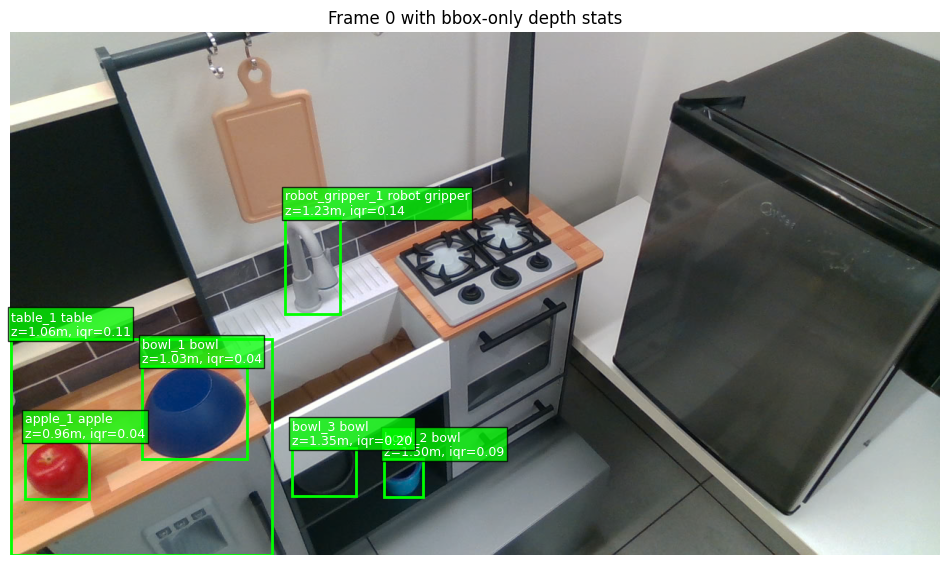

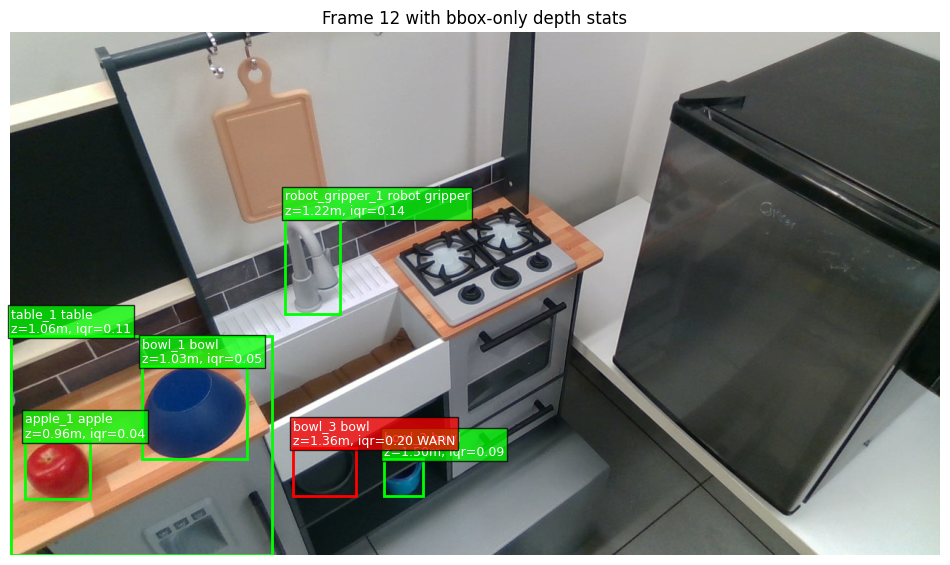

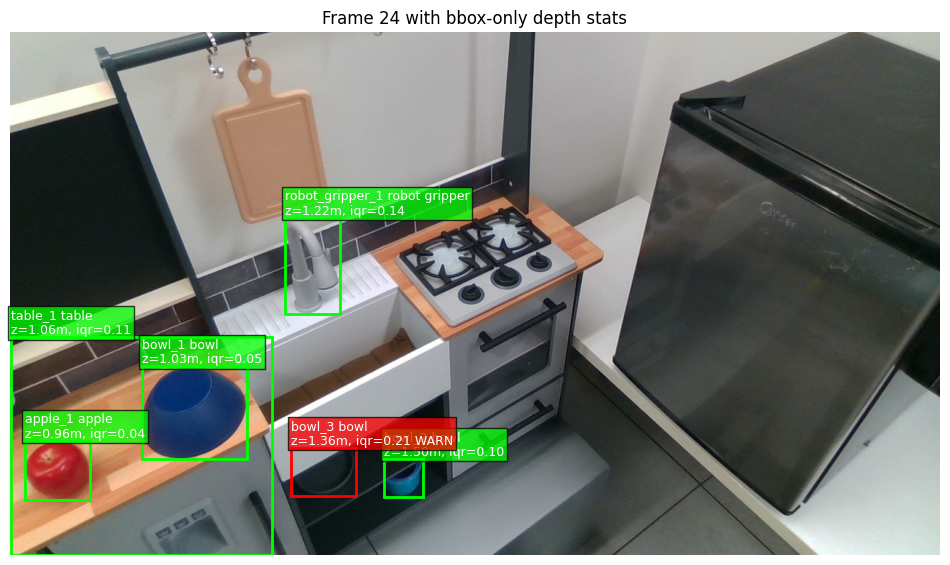

In [12]:
def draw_graph_on_frame(graph, figsize=(12, 7)):
    if Image is None:
        print("PIL is not installed, cannot display RGB frames.")
        return

    rgb = load_rgb_frame(graph["frame_id"])
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    ax = plt.gca()

    for node in graph["nodes"]:
        x1, y1, x2, y2 = node["bbox_xyxy"]
        color = "red" if node["flags"]["any_depth_trigger"] else "lime"
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=color, linewidth=2)
        ax.add_patch(rect)
        ds = node["depth_stats"]
        depth_text = "depth=NA" if ds["depth_median_m"] is None else f"z={ds['depth_median_m']:.2f}m"
        iqr_text = "iqr=NA" if ds["depth_iqr_m"] is None else f"iqr={ds['depth_iqr_m']:.2f}"
        warn = " WARN" if node["flags"]["any_depth_trigger"] else ""
        text = f"{node['object_id']} {node['label']}\n{depth_text}, {iqr_text}{warn}"
        ax.text(
            x1,
            max(0, y1 - 5),
            text,
            color="white",
            fontsize=9,
            bbox={"facecolor": color, "alpha": 0.75, "pad": 2},
        )

    plt.title(f"Frame {graph['frame_id']} with bbox-only depth stats")
    plt.axis("off")
    plt.show()


frames_with_nodes = [g for g in graphs if g["nodes"]]
if frames_with_nodes:
    sample_indices = np.linspace(0, len(frames_with_nodes) - 1, min(3, len(frames_with_nodes)), dtype=int)
    for idx in sample_indices:
        draw_graph_on_frame(frames_with_nodes[idx])
else:
    print("No nodes to visualize yet. Add or run detections, then rerun the graph cells.")

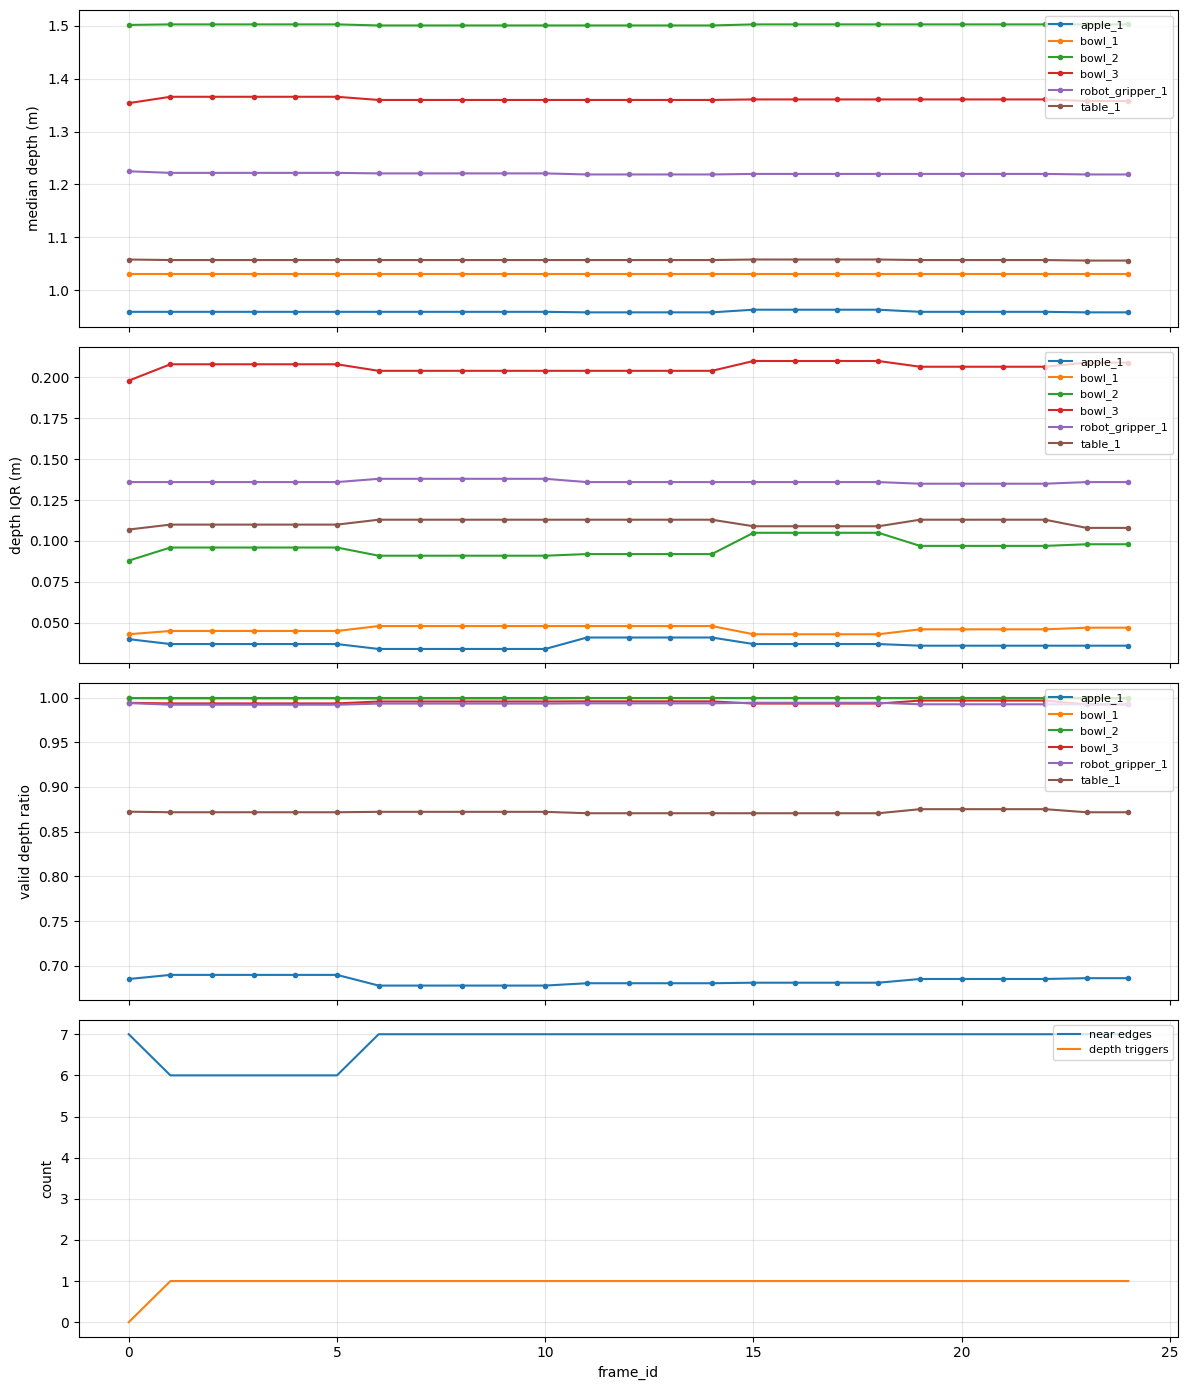

In [13]:
node_df = pd.DataFrame(node_rows)
if not node_df.empty:
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

    for object_id, group in node_df.groupby("object_id"):
        axes[0].plot(group["frame_id"], group["depth_median_m"], marker=".", label=object_id)
        axes[1].plot(group["frame_id"], group["depth_iqr_m"], marker=".", label=object_id)
        axes[2].plot(group["frame_id"], group["valid_depth_ratio"], marker=".", label=object_id)

    edge_counts = pd.DataFrame([
        {"frame_id": g["frame_id"], "near_edges": len(g["edges"])}
        for g in graphs
    ])
    trigger_counts = pd.DataFrame([
        {"frame_id": g["frame_id"], "depth_triggers": sum(n["flags"]["any_depth_trigger"] for n in g["nodes"])}
        for g in graphs
    ])
    axes[3].plot(edge_counts["frame_id"], edge_counts["near_edges"], label="near edges")
    axes[3].plot(trigger_counts["frame_id"], trigger_counts["depth_triggers"], label="depth triggers")

    axes[0].set_ylabel("median depth (m)")
    axes[1].set_ylabel("depth IQR (m)")
    axes[2].set_ylabel("valid depth ratio")
    axes[3].set_ylabel("count")
    axes[3].set_xlabel("frame_id")
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No node statistics to plot yet.")

## 14. Short interpretation

In [14]:
print("Temporal summary")
print(json.dumps(temporal_report["summary"], indent=2))
print()
print("Interpretation")
print(temporal_report["interpretation"])

print("\nReminder: this is a bbox-only baseline.")
print("- It does not use segmentation masks.")
print("- It does not implement the full REFLECT scene graph.")
print("- It only creates the relation type: near.")

Temporal summary
{
  "num_frames": 25,
  "num_frames_with_nodes": 25,
  "total_nodes": 150,
  "total_near_edges": 170,
  "mean_node_jaccard": 1.0,
  "mean_edge_jaccard": 0.9880952380952381,
  "total_any_depth_triggers": 24
}

Interpretation
Most unstable objects: ['bowl_3 (bowl)']. Frames with many depth triggers: [1, 2, 3, 4, 5]. Likely instability causes: ['high depth IQR or bbox includes background'].

Reminder: this is a bbox-only baseline.
- It does not use segmentation masks.
- It does not implement the full REFLECT scene graph.
- It only creates the relation type: near.
